In [1]:
# Install if needed:
# !pip install pymongo neo4j scikit-learn pandas matplotlib

import re
import json
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
from IPython.display import display

from pymongo import MongoClient
from neo4j import GraphDatabase

from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.facecolor'] = '#0f1117'
matplotlib.rcParams['axes.facecolor']   = '#161b22'
matplotlib.rcParams['text.color']       = '#e6edf3'
matplotlib.rcParams['axes.labelcolor']  = '#8b949e'
matplotlib.rcParams['xtick.color']      = '#8b949e'
matplotlib.rcParams['ytick.color']      = '#8b949e'

NOTEBOOK_CACHE = Path("../notebook_cache/03_graph_build")
NOTEBOOK_CACHE.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print("Neo4j graph results will be displayed directly inside this notebook.")

Imports OK
Neo4j graph results will be displayed directly inside this notebook.


In [2]:
# Connect to MongoDB output created by Member 1
mongo_client = MongoClient("mongodb://localhost:27017/", serverSelectionTimeoutMS=5000)
db = mongo_client["clpapers"]

try:
    mongo_version = mongo_client.server_info()["version"]
    print("Connected to MongoDB version:", mongo_version)
except Exception as e:
    print("MongoDB connection failed. Make sure MongoDB is running on localhost:27017.")
    raise e

chunks = list(db.chunks.find({}, {"_id": 0}))
metadata_list = list(db.metadata.find({}, {"_id": 0}))

if len(chunks) == 0:
    raise ValueError("No chunks found in MongoDB. Run 01_ingestion_pipeline.ipynb first.")

if len(metadata_list) == 0:
    raise ValueError("No metadata found in MongoDB. Run 01_ingestion_pipeline.ipynb first.")

print(f"Chunks loaded from MongoDB: {len(chunks)}")
print(f"Metadata records loaded from MongoDB: {len(metadata_list)}")
print(f"Unique papers in chunks: {len(set(c['paper_id'] for c in chunks))}")

print("\nSample chunk keys:")
print(list(chunks[0].keys()))

print("\nSample metadata keys:")
print(list(metadata_list[0].keys()))

display(pd.DataFrame([{
    "chunks_loaded": len(chunks),
    "metadata_records": len(metadata_list),
    "unique_papers": len(set(c["paper_id"] for c in chunks))
}]))

Connected to MongoDB version: 8.0.23
Chunks loaded from MongoDB: 6728
Metadata records loaded from MongoDB: 208
Unique papers in chunks: 208

Sample chunk keys:
['chunk_id', 'paper_id', 'chunk_index', 'start_word', 'end_word', 'word_count', 'page_start', 'page_end', 'text', 'title', 'authors', 'year']

Sample metadata keys:
['paper_id', 'filename', 'title', 'authors', 'year', 'page_count', 'size_bytes', 'md5', 'filepath']


,chunks_loaded,metadata_records,unique_papers
0,6728,208,208


In [3]:
def clean_text(text):
    text = "" if text is None else str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def split_authors(authors_value):
    # The ingestion notebook stores authors as semicolon-separated strings.
    if authors_value is None:
        return []

    if isinstance(authors_value, list):
        raw_authors = authors_value
    else:
        raw_authors = str(authors_value).split(";")

    authors = []
    for author in raw_authors:
        name = clean_text(author)
        if name and name.lower() not in {"unknown", "none", "nan"}:
            authors.append(name)

    return authors


def extract_abstract_like_text(first_chunks_text):
    # Try to extract text around the abstract; otherwise use the first part.
    text = clean_text(first_chunks_text)
    lower = text.lower()

    abstract_pos = lower.find("abstract")
    intro_pos = lower.find("introduction")

    if abstract_pos != -1 and intro_pos != -1 and intro_pos > abstract_pos:
        return text[abstract_pos:intro_pos].strip()

    if abstract_pos != -1:
        return text[abstract_pos:abstract_pos + 1800].strip()

    return text[:1800].strip()


# Group chunks by paper_id
chunks_by_paper = defaultdict(list)

for chunk in chunks:
    chunks_by_paper[chunk["paper_id"]].append(chunk)

for paper_id in chunks_by_paper:
    chunks_by_paper[paper_id] = sorted(
        chunks_by_paper[paper_id],
        key=lambda x: x.get("chunk_index", 0)
    )


papers = []

for meta in metadata_list:
    paper_id = meta.get("paper_id")
    paper_chunks = chunks_by_paper.get(paper_id, [])

    first_chunks_text = " ".join(c.get("text", "") for c in paper_chunks[:3])
    abstract_like = extract_abstract_like_text(first_chunks_text)

    paper_record = {
        "paper_id": paper_id,
        "title": clean_text(meta.get("title", "unknown")),
        "authors_raw": meta.get("authors", "unknown"),
        "authors": split_authors(meta.get("authors", "unknown")),
        "year": str(meta.get("year", "unknown")),
        "filename": meta.get("filename", ""),
        "filepath": meta.get("filepath", ""),
        "page_count": meta.get("page_count", None),
        "abstract_like": abstract_like,
        "full_topic_text": clean_text(meta.get("title", "") + " " + abstract_like),
        "chunk_count": len(paper_chunks)
    }

    papers.append(paper_record)

papers_df = pd.DataFrame([{
    "paper_id": p["paper_id"],
    "title": p["title"],
    "year": p["year"],
    "authors_count": len(p["authors"]),
    "chunk_count": p["chunk_count"]
} for p in papers])

print(f"Prepared paper records: {len(papers)}")
display(papers_df.head())

print("Sample paper record:")
print(json.dumps({
    "paper_id": papers[0]["paper_id"],
    "title": papers[0]["title"],
    "authors": papers[0]["authors"][:5],
    "year": papers[0]["year"],
    "abstract_like": papers[0]["abstract_like"][:500]
}, indent=2, ensure_ascii=False))

Prepared paper records: 208


,paper_id,title,year,authors_count,chunk_count
0,paper1,FlexSQL: Flexible Exploration and Execution Ma...,2026,8,26
1,paper2,Reinforcement Learning for LLM-based Multi-Age...,2026,1,92
2,paper3,mdok-style at SemEval-2026 Task 10: Finetuning...,2026,1,8
3,paper4,mdok-style at SemEval-2026 Task 9: Finetuning ...,2026,3,14
4,paper5,Fuzzy Fingerprinting Encoder Pre-trained Langu...,2026,3,20


Sample paper record:
{
  "paper_id": "paper1",
  "title": "FlexSQL: Flexible Exploration and Execution Make Better Text-to-SQL Agents",
  "authors": [
    "Quang Hieu Pham",
    "Yang He",
    "Ping Nie",
    "Canwen Xu",
    "Davood Rafiei"
  ],
  "year": "2026",
  "abstract_like": "Abstract Text-to-SQL over large analytical databases requires navigating complex schemas, resolving ambiguous queries, and grounding decisions in actual data. Most current systems follow a fixed pipeline where schema elements are retrieved once upfront and the database is only revisited for post-hoc repair, limiting recovery from early mistakes. We present FlexSQL, a text- to-SQL agent whose core design principle is flexible database interaction: the agent can explore schema structure, inspect d"
}


In [4]:
CONTROLLED_TOPICS = {
    "Retrieval-Augmented Generation": [
        "rag", "retrieval augmented generation",
        "retrieval-augmented generation", "retrieval enhanced generation"
    ],
    "Large Language Models": [
        "llm", "llms", "large language model",
        "large language models", "foundation model", "foundation models"
    ],
    "Information Retrieval": [
        "information retrieval", "document retrieval",
        "retrieval system", "retrieval systems"
    ],
    "Dense Retrieval": [
        "dense retrieval", "neural retrieval", "embedding retrieval", "vector search"
    ],
    "Hybrid Search": [
        "hybrid search", "hybrid retrieval", "sparse dense retrieval",
        "bm25 dense", "sparse and dense retrieval"
    ],
    "Reranking": [
        "reranking", "re ranking", "re-ranking", "reranker",
        "ranker", "cross encoder reranker"
    ],
    "Question Answering": [
        "question answering", "qa", "open domain question answering",
        "open-domain question answering"
    ],
    "Text Summarization": [
        "summarization", "text summarization",
        "abstractive summarization", "extractive summarization"
    ],
    "Machine Translation": [
        "machine translation", "neural machine translation", "translation"
    ],
    "Text-to-SQL": [
        "text-to-sql", "text to sql", "semantic parsing", "sql generation"
    ],
    "Named Entity Recognition": [
        "named entity recognition", "ner", "entity extraction"
    ],
    "Text Classification": [
        "text classification", "document classification", "classification task"
    ],
    "Sentiment Analysis": [
        "sentiment analysis", "opinion mining"
    ],
    "Dialogue Systems": [
        "dialogue system", "dialogue systems", "conversational agent", "chatbot", "chatbots"
    ],
    "LLM Agents": [
        "llm agent", "llm agents", "language agent", "language agents",
        "tool using agent", "tool-use", "tool use"
    ],
    "Prompt Engineering": [
        "prompt engineering", "prompting", "prompt design", "chain of thought", "cot"
    ],
    "Instruction Tuning": [
        "instruction tuning", "instruction following", "supervised fine tuning", "sft"
    ],
    "Fine-Tuning": [
        "fine tuning", "fine-tuning", "parameter efficient tuning", "peft", "lora"
    ],
    "LLM Evaluation": [
        "llm evaluation", "model evaluation", "evaluation benchmark",
        "benchmarking", "benchmark"
    ],
    "Hallucination Detection": [
        "hallucination", "hallucinations", "factuality", "faithfulness", "fact verification"
    ],
    "Safety and Bias": [
        "safety", "bias", "fairness", "toxicity", "alignment"
    ],
    "Multilingual NLP": [
        "multilingual", "cross lingual", "cross-lingual", "multilingual nlp"
    ],
    "Low-Resource NLP": [
        "low resource", "low-resource", "few shot", "few-shot", "zero shot", "zero-shot"
    ],
    "Knowledge Graphs": [
        "knowledge graph", "knowledge graphs", "graph rag", "graphrag",
        "graph retrieval augmented generation"
    ],
    "Embeddings": [
        "embedding", "embeddings", "sentence embedding",
        "text embedding", "representation learning"
    ],
    "Code Generation": [
        "code generation", "program synthesis", "coding agent", "software engineering"
    ],
    "Reasoning": [
        "reasoning", "mathematical reasoning", "logical reasoning",
        "multi step reasoning", "multi-step reasoning"
    ]
}

print(f"Controlled topic vocabulary size: {len(CONTROLLED_TOPICS)}")
display(pd.DataFrame([
    {"topic": topic, "aliases": ", ".join(aliases[:4])}
    for topic, aliases in CONTROLLED_TOPICS.items()
]).head(15))

Controlled topic vocabulary size: 27


,topic,aliases
0,Retrieval-Augmented Generation,"rag, retrieval augmented generation, retrieval..."
1,Large Language Models,"llm, llms, large language model, large languag..."
2,Information Retrieval,"information retrieval, document retrieval, ret..."
3,Dense Retrieval,"dense retrieval, neural retrieval, embedding r..."
4,Hybrid Search,"hybrid search, hybrid retrieval, sparse dense ..."
5,Reranking,"reranking, re ranking, re-ranking, reranker"
6,Question Answering,"question answering, qa, open domain question a..."
7,Text Summarization,"summarization, text summarization, abstractive..."
8,Machine Translation,"machine translation, neural machine translatio..."
9,Text-to-SQL,"text-to-sql, text to sql, semantic parsing, sq..."


In [5]:
GENERIC_TERMS = {
    "method", "methods", "approach", "approaches", "result", "results",
    "performance", "dataset", "datasets", "experiment", "experiments",
    "model", "models", "paper", "papers", "study", "studies", "task", "tasks",
    "system", "systems", "framework", "frameworks", "proposed method",
    "new method", "analysis", "evaluation", "training", "testing", "data",
    "research", "language", "learning", "using", "based", "new", "towards",
    "improving", "efficient", "robust", "automatic", "large scale", "state art"
}

BAD_PHRASE_PARTS = {
    "arxiv", "preprint", "appendix", "figure", "table", "section",
    "et al", "copyright", "license"
}


def normalize_for_match(text):
    text = "" if text is None else str(text)
    text = text.lower()
    text = text.replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def contains_phrase(text_norm, phrase_norm):
    if not text_norm or not phrase_norm:
        return False

    pattern = r"\b" + re.escape(phrase_norm) + r"\b"
    return re.search(pattern, text_norm) is not None


def is_valid_extracted_topic(phrase):
    phrase_norm = normalize_for_match(phrase)

    if not phrase_norm:
        return False

    if phrase_norm in GENERIC_TERMS:
        return False

    if any(bad in phrase_norm for bad in BAD_PHRASE_PARTS):
        return False

    words = phrase_norm.split()

    # Prefer meaningful research phrases
    if len(words) < 2:
        return False

    if len(words) > 5:
        return False

    # Remove phrases that are mostly numbers
    if sum(ch.isdigit() for ch in phrase_norm) > len(phrase_norm) / 2:
        return False

    # Remove phrases containing too many generic words
    generic_count = sum(1 for w in words if w in GENERIC_TERMS)
    if generic_count >= max(1, len(words) - 1):
        return False

    return True


def match_controlled_topics(paper):
    # Matches controlled topic aliases against title first, then abstract-like text.
    title = paper.get("title", "")
    abstract_like = paper.get("abstract_like", "")

    title_norm = normalize_for_match(title)
    abstract_norm = normalize_for_match(abstract_like)

    matches = {}

    for canonical_topic, aliases in CONTROLLED_TOPICS.items():
        best_match = None

        for alias in aliases:
            alias_norm = normalize_for_match(alias)

            if contains_phrase(title_norm, alias_norm):
                best_match = {
                    "topic": canonical_topic,
                    "topic_type": "controlled",
                    "source": "controlled_title",
                    "evidence": alias,
                    "confidence": 0.95
                }
                break

            if contains_phrase(abstract_norm, alias_norm):
                candidate = {
                    "topic": canonical_topic,
                    "topic_type": "controlled",
                    "source": "controlled_abstract",
                    "evidence": alias,
                    "confidence": 0.82
                }

                if best_match is None or candidate["confidence"] > best_match["confidence"]:
                    best_match = candidate

        if best_match:
            matches[canonical_topic] = best_match

    return list(matches.values())


# Quick test on first paper
print("Controlled topic matches for first paper:")
display(pd.DataFrame(match_controlled_topics(papers[0])))

Controlled topic matches for first paper:


,topic,topic_type,source,evidence,confidence
0,Text-to-SQL,controlled,controlled_title,text-to-sql,0.95
1,Code Generation,controlled,controlled_abstract,coding agent,0.82
2,Reasoning,controlled,controlled_abstract,reasoning,0.82


In [6]:
paper_texts = [p["full_topic_text"] for p in papers]

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(2, 4),
    max_features=3000,
    min_df=1
)

tfidf_matrix = vectorizer.fit_transform(paper_texts)
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF keyphrase matrix:", tfidf_matrix.shape)
print("Feature examples:", feature_names[:15])

TF-IDF keyphrase matrix: (208, 3000)
Feature examples: ['07 https' '07 https doi' '07 https doi org' '10 1145' '10 1145 3805712'
 '1145 3805712' '19 46' '20 24' '20 24 2026' '20 24 2026 melbourne'
 '20 30' '20 30 40' '20 30 40 50' '2010 2024' '2026 07']


In [7]:
def get_top_keyphrases_for_paper(row_index, top_n=15):
    row = tfidf_matrix[row_index]
    scores = row.toarray().flatten()
    top_indices = scores.argsort()[::-1]

    phrases = []
    for idx in top_indices:
        score = scores[idx]

        if score <= 0:
            break

        phrase = feature_names[idx]

        if is_valid_extracted_topic(phrase):
            phrases.append({
                "phrase": phrase,
                "score": float(score)
            })

        if len(phrases) >= top_n:
            break

    return phrases


# Count how many papers contain each extracted phrase
phrase_doc_freq = Counter()

for i in range(len(papers)):
    phrases = get_top_keyphrases_for_paper(i, top_n=20)
    unique_phrases = set(p["phrase"] for p in phrases)
    for phrase in unique_phrases:
        phrase_doc_freq[phrase] += 1


print("Example fallback keyphrases for first paper:")
display(pd.DataFrame(get_top_keyphrases_for_paper(0, top_n=10)))

Example fallback keyphrases for first paper:


,phrase,score
0,text sql,0.598421
1,spider2 snow,0.398947
2,claude code,0.185157
3,post hoc,0.174998
4,oss 120b,0.174998
5,level errors,0.174998
6,gpt oss 120b,0.174998
7,gpt oss,0.174998
8,agents abstract,0.160681
9,open source,0.146364


In [8]:
MIN_CONTROLLED_TOPICS = 2
MAX_TOPICS_PER_PAPER = 6


def phrase_appears_in_title(phrase, title):
    return contains_phrase(
        normalize_for_match(title),
        normalize_for_match(phrase)
    )


def assign_topics_to_paper(paper, row_index):
    controlled = match_controlled_topics(paper)
    final_topics = {t["topic"]: t for t in controlled}

    # Use extracted keywords only when controlled coverage is weak
    if len(controlled) < MIN_CONTROLLED_TOPICS:
        extracted_phrases = get_top_keyphrases_for_paper(row_index, top_n=20)

        for item in extracted_phrases:
            phrase = item["phrase"]
            tfidf_score = item["score"]

            appears_in_title = phrase_appears_in_title(phrase, paper["title"])
            appears_in_multiple_papers = phrase_doc_freq[phrase] >= 2

            # Accept a new discovered topic if it is prominent in the title
            # or it appears across multiple papers.
            if not appears_in_title and not appears_in_multiple_papers:
                continue

            topic_name = phrase.title()

            # Discovered topics have lower confidence than controlled topics.
            confidence = 0.72 if appears_in_title else 0.65

            if appears_in_multiple_papers:
                confidence += 0.04

            confidence = min(confidence, 0.78)

            if topic_name not in final_topics:
                final_topics[topic_name] = {
                    "topic": topic_name,
                    "topic_type": "discovered",
                    "source": "extracted_keyphrase",
                    "evidence": phrase,
                    "confidence": round(confidence, 2),
                    "tfidf_score": round(tfidf_score, 4),
                    "doc_frequency": int(phrase_doc_freq[phrase])
                }

            if len(final_topics) >= MAX_TOPICS_PER_PAPER:
                break

    sorted_topics = sorted(
        final_topics.values(),
        key=lambda x: x["confidence"],
        reverse=True
    )

    return sorted_topics[:MAX_TOPICS_PER_PAPER]


for i, paper in enumerate(papers):
    paper["topics"] = assign_topics_to_paper(paper, i)

topic_rows = []
for paper in papers:
    for topic in paper["topics"]:
        topic_rows.append({
            "paper_id": paper["paper_id"],
            "title": paper["title"],
            "topic": topic["topic"],
            "topic_type": topic["topic_type"],
            "source": topic["source"],
            "evidence": topic["evidence"],
            "confidence": topic["confidence"],
            "tfidf_score": topic.get("tfidf_score", None),
            "doc_frequency": topic.get("doc_frequency", None)
        })

topic_assignment_df = pd.DataFrame(topic_rows)

print("Topic assignment sample:")
display(topic_assignment_df.head(20))

topic_summary_df = topic_assignment_df.groupby(["topic", "topic_type"]).agg(
    papers=("paper_id", "nunique"),
    avg_confidence=("confidence", "mean")
).reset_index().sort_values(["papers", "avg_confidence"], ascending=False)

print("Top topics:")
display(topic_summary_df.head(25))

print("Topic assignment counts:")
display(pd.DataFrame([{
    "papers": len(papers),
    "topic_assignments": len(topic_assignment_df),
    "unique_topics": topic_assignment_df["topic"].nunique(),
    "controlled_assignments": int((topic_assignment_df["topic_type"] == "controlled").sum()),
    "discovered_assignments": int((topic_assignment_df["topic_type"] == "discovered").sum())
}]))

Topic assignment sample:


,paper_id,title,topic,topic_type,source,evidence,confidence,tfidf_score,doc_frequency
0,paper1,FlexSQL: Flexible Exploration and Execution Ma...,Text-to-SQL,controlled,controlled_title,text-to-sql,0.95,NaN,NaN
1,paper1,FlexSQL: Flexible Exploration and Execution Ma...,Code Generation,controlled,controlled_abstract,coding agent,0.82,NaN,NaN
2,paper1,FlexSQL: Flexible Exploration and Execution Ma...,Reasoning,controlled,controlled_abstract,reasoning,0.82,NaN,NaN
3,paper2,Reinforcement Learning for LLM-based Multi-Age...,Large Language Models,controlled,controlled_title,llm,0.95,NaN,NaN
4,paper2,Reinforcement Learning for LLM-based Multi-Age...,LLM Agents,controlled,controlled_abstract,llm agents,0.82,NaN,NaN
5,paper2,Reinforcement Learning for LLM-based Multi-Age...,Safety and Bias,controlled,controlled_abstract,safety,0.82,NaN,NaN
6,paper3,mdok-style at SemEval-2026 Task 10: Finetuning...,Large Language Models,controlled,controlled_title,llms,0.95,NaN,NaN
7,paper3,mdok-style at SemEval-2026 Task 10: Finetuning...,Text Classification,controlled,controlled_abstract,text classification,0.82,NaN,NaN
8,paper4,mdok-style at SemEval-2026 Task 9: Finetuning ...,Large Language Models,controlled,controlled_title,llms,0.95,NaN,NaN
9,paper4,mdok-style at SemEval-2026 Task 9: Finetuning ...,Multilingual NLP,controlled,controlled_title,multilingual,0.95,NaN,NaN


Top topics:


,topic,topic_type,papers,avg_confidence
120,Large Language Models,controlled,134,0.884030
114,LLM Evaluation,controlled,52,0.860000
215,Reasoning,controlled,46,0.876522
241,Safety and Bias,controlled,39,0.846667
62,Fine-Tuning,controlled,36,0.845278
165,Multilingual NLP,controlled,19,0.861053
210,Question Answering,controlled,18,0.834444
47,Embeddings,controlled,16,0.844375
206,Prompt Engineering,controlled,16,0.836250
141,Low-Resource NLP,controlled,13,0.850000


Topic assignment counts:


,papers,topic_assignments,unique_topics,controlled_assignments,discovered_assignments
0,208,776,284,474,302


In [11]:
NEO4J_URI = "neo4j+s://31a35718.databases.neo4j.io"
NEO4J_USER = "31a35718"
NEO4J_PASSWORD = "4a5QbeBuQy47jPN0-tVX4TlGZPHsZQUKPASOtNSCp2g"

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USER, NEO4J_PASSWORD)
)

def run_cypher(query, parameters=None):
    with driver.session() as session:
        result = session.run(query, parameters or {})
        return [record.data() for record in result]

try:
    test_result = run_cypher("RETURN 'Neo4j connection OK' AS status")
    print(test_result[0]["status"])
except Exception as e:
    print("Neo4j connection failed.")
    print("Check that Neo4j is running and that NEO4J_PASSWORD is correct.")
    raise e

Neo4j connection OK


In [12]:
# WARNING: this deletes the current Neo4j database content
CLEAR_GRAPH = True

if CLEAR_GRAPH:
    run_cypher("MATCH (n) DETACH DELETE n")
    print("Old Neo4j graph cleared.")

constraint_queries = [
    "CREATE CONSTRAINT paper_id_unique IF NOT EXISTS FOR (p:Paper) REQUIRE p.paper_id IS UNIQUE",
    "CREATE CONSTRAINT author_name_unique IF NOT EXISTS FOR (a:Author) REQUIRE a.name IS UNIQUE",
    "CREATE CONSTRAINT topic_name_unique IF NOT EXISTS FOR (t:Topic) REQUIRE t.name IS UNIQUE"
]

for q in constraint_queries:
    run_cypher(q)

print("Constraints created or already existed.")

Old Neo4j graph cleared.
Constraints created or already existed.


In [13]:
def prepare_paper_for_neo4j(paper):
    return {
        "paper_id": paper["paper_id"],
        "title": paper["title"],
        "year": paper["year"],
        "filename": paper["filename"],
        "filepath": paper["filepath"],
        "page_count": paper["page_count"] if paper["page_count"] is not None else 0,
        "chunk_count": paper["chunk_count"],
        "authors": paper["authors"],
        "topics": paper["topics"]
    }


neo4j_papers = [prepare_paper_for_neo4j(p) for p in papers]

insert_query = """
UNWIND $papers AS paper

MERGE (p:Paper {paper_id: paper.paper_id})
SET p.title = paper.title,
    p.year = paper.year,
    p.filename = paper.filename,
    p.filepath = paper.filepath,
    p.page_count = paper.page_count,
    p.chunk_count = paper.chunk_count

WITH p, paper
UNWIND paper.authors AS author_name
MERGE (a:Author {name: author_name})
MERGE (a)-[:WROTE]->(p)

WITH p, paper
UNWIND paper.topics AS topic_data
MERGE (t:Topic {name: topic_data.topic})
ON CREATE SET t.topic_type = topic_data.topic_type
SET t.topic_type =
    CASE
        WHEN topic_data.topic_type = 'controlled' THEN 'controlled'
        ELSE coalesce(t.topic_type, topic_data.topic_type)
    END

MERGE (p)-[r:HAS_TOPIC]->(t)
SET r.source = topic_data.source,
    r.evidence = topic_data.evidence,
    r.confidence = topic_data.confidence,
    r.topic_type = topic_data.topic_type,
    r.tfidf_score = coalesce(topic_data.tfidf_score, 0.0),
    r.doc_frequency = coalesce(topic_data.doc_frequency, 0)
"""

run_cypher(insert_query, {"papers": neo4j_papers})

print(f"Inserted/merged papers into Neo4j: {len(neo4j_papers)}")

Inserted/merged papers into Neo4j: 208


In [14]:
TOPIC_HIERARCHY = [
    ("Retrieval-Augmented Generation", "Information Retrieval"),
    ("Dense Retrieval", "Information Retrieval"),
    ("Hybrid Search", "Information Retrieval"),
    ("Reranking", "Information Retrieval"),
    ("Question Answering", "Natural Language Processing"),
    ("Text Summarization", "Natural Language Processing"),
    ("Machine Translation", "Natural Language Processing"),
    ("Named Entity Recognition", "Natural Language Processing"),
    ("Text Classification", "Natural Language Processing"),
    ("Sentiment Analysis", "Natural Language Processing"),
    ("Dialogue Systems", "Natural Language Processing"),
    ("Text-to-SQL", "Semantic Parsing"),
    ("LLM Evaluation", "Large Language Models"),
    ("Hallucination Detection", "LLM Evaluation"),
    ("Prompt Engineering", "Large Language Models"),
    ("Instruction Tuning", "Large Language Models"),
    ("Fine-Tuning", "Large Language Models"),
    ("LLM Agents", "Large Language Models"),
    ("Code Generation", "Large Language Models"),
    ("Reasoning", "Large Language Models"),
    ("Safety and Bias", "Large Language Models"),
    ("Knowledge Graphs", "Natural Language Processing"),
    ("Embeddings", "Natural Language Processing")
]

hierarchy_query = """
UNWIND $pairs AS pair
MERGE (child:Topic {name: pair.child})
MERGE (parent:Topic {name: pair.parent})
MERGE (child)-[:SUBTOPIC_OF]->(parent)
"""

run_cypher(
    hierarchy_query,
    {"pairs": [{"child": child, "parent": parent} for child, parent in TOPIC_HIERARCHY]}
)

print("Topic hierarchy inserted.")

Topic hierarchy inserted.


In [15]:
summary_queries = {
    "papers": "MATCH (p:Paper) RETURN count(p) AS count",
    "authors": "MATCH (a:Author) RETURN count(a) AS count",
    "topics": "MATCH (t:Topic) RETURN count(t) AS count",
    "WROTE relationships": "MATCH ()-[r:WROTE]->() RETURN count(r) AS count",
    "HAS_TOPIC relationships": "MATCH ()-[r:HAS_TOPIC]->() RETURN count(r) AS count",
    "SUBTOPIC_OF relationships": "MATCH ()-[r:SUBTOPIC_OF]->() RETURN count(r) AS count"
}

summary_rows = []

for name, query in summary_queries.items():
    result = run_cypher(query)
    summary_rows.append({"graph_item": name, "count": result[0]["count"]})

graph_summary_df = pd.DataFrame(summary_rows)

print("=" * 50)
print("NEO4J GRAPH SUMMARY")
print("=" * 50)
display(graph_summary_df)

NEO4J GRAPH SUMMARY


,graph_item,count
0,papers,208
1,authors,951
2,topics,286
3,WROTE relationships,981
4,HAS_TOPIC relationships,776
5,SUBTOPIC_OF relationships,23


In [16]:
sample_query = """
MATCH (a:Author)-[:WROTE]->(p:Paper)-[r:HAS_TOPIC]->(t:Topic)
RETURN p.paper_id AS paper_id,
       p.title AS title,
       collect(DISTINCT a.name)[0..5] AS authors,
       collect(DISTINCT {
           topic: t.name,
           source: r.source,
           evidence: r.evidence,
           confidence: r.confidence
       })[0..6] AS topics
LIMIT 5
"""

samples = run_cypher(sample_query)
display(pd.DataFrame(samples))

,paper_id,title,authors,topics
0,paper1,FlexSQL: Flexible Exploration and Execution Ma...,"[Quang Hieu Pham, Yang He, Ping Nie, Canwen Xu...","[{'confidence': 0.95, 'evidence': 'text-to-sql..."
1,paper2,Reinforcement Learning for LLM-based Multi-Age...,[Chenchen Zhang],"[{'confidence': 0.95, 'evidence': 'llm', 'sour..."
2,paper3,mdok-style at SemEval-2026 Task 10: Finetuning...,[Dominik Macko],"[{'confidence': 0.95, 'evidence': 'llms', 'sou..."
3,paper4,mdok-style at SemEval-2026 Task 9: Finetuning ...,"[Dominik Macko, Alok Debnath, Jakub Simko]","[{'confidence': 0.95, 'evidence': 'llms', 'sou..."
4,paper5,Fuzzy Fingerprinting Encoder Pre-trained Langu...,"[Patrícia Pereira, Helena Moniz, Joao Paulo Ca...","[{'confidence': 0.82, 'evidence': 'embeddings'..."


In [17]:
query = """
MATCH (p:Paper)-[r:HAS_TOPIC]->(t:Topic)
RETURN t.name AS topic,
       t.topic_type AS topic_type,
       count(DISTINCT p) AS papers,
       round(avg(r.confidence), 3) AS avg_confidence
ORDER BY papers DESC, avg_confidence DESC
LIMIT 20
"""

top_topics_df = pd.DataFrame(run_cypher(query))
display(top_topics_df)

,topic,topic_type,papers,avg_confidence
0,Large Language Models,controlled,134,0.884
1,LLM Evaluation,controlled,52,0.860
2,Reasoning,controlled,46,0.877
3,Safety and Bias,controlled,39,0.847
4,Fine-Tuning,controlled,36,0.845
5,Multilingual NLP,controlled,19,0.861
6,Question Answering,controlled,18,0.834
7,Embeddings,controlled,16,0.844
8,Prompt Engineering,controlled,16,0.836
9,Low-Resource NLP,controlled,13,0.850


In [18]:
query = """
MATCH (p1:Paper)-[r1:HAS_TOPIC]->(t:Topic)<-[r2:HAS_TOPIC]-(p2:Paper)
WHERE p1.paper_id < p2.paper_id
RETURN p1.paper_id AS paper1_id,
       p1.title AS paper1_title,
       t.name AS shared_topic,
       p2.paper_id AS paper2_id,
       p2.title AS paper2_title,
       round((r1.confidence + r2.confidence) / 2, 3) AS connection_confidence
ORDER BY connection_confidence DESC
LIMIT 20
"""

shared_topic_df = pd.DataFrame(run_cypher(query))
display(shared_topic_df)

,paper1_id,paper1_title,shared_topic,paper2_id,paper2_title,connection_confidence
0,paper100,CLEAR: Revealing How Noise and Ambiguity Degra...,Large Language Models,paper117,Perturbation Dose Responses in Recursive LLM L...,0.95
1,paper113,Measuring AI Reasoning: A Guide for Researchers,Reasoning,paper120,Flexi-LoRA with Input-Adaptive Ranks: Efficien...,0.95
2,paper100,CLEAR: Revealing How Noise and Ambiguity Degra...,Large Language Models,paper116,Zero-Shot Confidence Estimation for Small LLMs...,0.95
3,paper115,Fight Poison with Poison: Enhancing Robustness...,Low-Resource NLP,paper116,Zero-Shot Confidence Estimation for Small LLMs...,0.95
4,paper116,Zero-Shot Confidence Estimation for Small LLMs...,Large Language Models,paper117,Perturbation Dose Responses in Recursive LLM L...,0.95
5,paper112,Shadow-Loom: Causal Reasoning over Graphical W...,Reasoning,paper120,Flexi-LoRA with Input-Adaptive Ranks: Efficien...,0.95
6,paper103,DIAGRAMS: A Review Framework for Reasoning-Lev...,Reasoning,paper112,Shadow-Loom: Causal Reasoning over Graphical W...,0.95
7,paper10,Dependency Parsing Across the Resource Spectru...,Low-Resource NLP,paper115,Fight Poison with Poison: Enhancing Robustness...,0.95
8,paper109,Foundation Models to Unlock Real-World Evidenc...,Large Language Models,paper116,Zero-Shot Confidence Estimation for Small LLMs...,0.95
9,paper10,Dependency Parsing Across the Resource Spectru...,Low-Resource NLP,paper116,Zero-Shot Confidence Estimation for Small LLMs...,0.95


In [19]:
query = """
MATCH (p1:Paper)<-[:WROTE]-(a:Author)-[:WROTE]->(p2:Paper)
WHERE p1.paper_id < p2.paper_id
RETURN a.name AS shared_author,
       p1.paper_id AS paper1_id,
       p1.title AS paper1_title,
       p2.paper_id AS paper2_id,
       p2.title AS paper2_title
LIMIT 20
"""

shared_author_df = pd.DataFrame(run_cypher(query))
display(shared_author_df)

,shared_author,paper1_id,paper1_title,paper2_id,paper2_title
0,Atticus Geiger,paper118,Bucketing the Good Apples: A Method for Diagno...,paper132,Arithmetic in the Wild: Llama uses Base-10 Add...
1,Jacob Andreas,paper166,Training Language Models to Explain Their Own ...,paper171,Language and Experience: A Computational Model...
2,Dominik Macko,paper3,mdok-style at SemEval-2026 Task 10: Finetuning...,paper4,mdok-style at SemEval-2026 Task 9: Finetuning ...
3,Huajun Chen,paper138,OceanPile: A Large-Scale Multimodal Ocean Corp...,paper42,StressEval: Failure-Driven Dynamic Benchmarkin...
4,Wei Liu,paper121,LLM-Augmented Semantic Steering of Text Embedd...,paper46,The Cylindrical Representation Hypothesis for ...
5,Kwan Soo Shin,paper48,The Compliance Gap: Why AI Systems Promise to ...,paper53,The Reasoning Trap: An Information-Theoretic B...
6,Mario Rodríguez Béjar,paper106,FunFuzz: An LLM-Powered Evolutionary Fuzzing F...,paper6,ContextualJailbreak: Evolutionary Red-Teaming ...
7,Jose L. Hernández-Ramos,paper106,FunFuzz: An LLM-Powered Evolutionary Fuzzing F...,paper6,ContextualJailbreak: Evolutionary Red-Teaming ...
8,Linh Ngo Van,paper71,MemORAI: Memory Organization and Retrieval via...,paper73,MTA: Multi-Granular Trajectory Alignment for L...
9,Trung Le,paper71,MemORAI: Memory Organization and Retrieval via...,paper73,MTA: Multi-Granular Trajectory Alignment for L...


In [20]:
# Example seed paper.
# Later, this can come from Qdrant/BM25/dense/hybrid retrieval result.
seed_paper_id = papers[0]["paper_id"]

query = """
MATCH (seed:Paper {paper_id: $paper_id})

OPTIONAL MATCH (seed)-[sr:HAS_TOPIC]->(t:Topic)<-[tr:HAS_TOPIC]-(related_by_topic:Paper)
WHERE related_by_topic <> seed

OPTIONAL MATCH (seed)<-[:WROTE]-(a:Author)-[:WROTE]->(related_by_author:Paper)
WHERE related_by_author <> seed

RETURN seed.paper_id AS seed_paper_id,
       seed.title AS seed_title,
       collect(DISTINCT {
           paper_id: related_by_topic.paper_id,
           title: related_by_topic.title,
           reason: "shared_topic",
           topic: t.name,
           confidence: tr.confidence
       })[0..10] AS topic_expansion,
       collect(DISTINCT {
           paper_id: related_by_author.paper_id,
           title: related_by_author.title,
           reason: "shared_author",
           author: a.name
       })[0..10] AS author_expansion
"""

graphrag_expansion = run_cypher(query, {"paper_id": seed_paper_id})

print("GraphRAG expansion seed paper:")
print(seed_paper_id)

display(pd.DataFrame(graphrag_expansion))

GraphRAG expansion seed paper:
paper1


,seed_paper_id,seed_title,topic_expansion,author_expansion
0,paper1,FlexSQL: Flexible Exploration and Execution Ma...,"[{'reason': 'shared_topic', 'confidence': 0.82...","[{'reason': 'shared_author', 'author': None, '..."


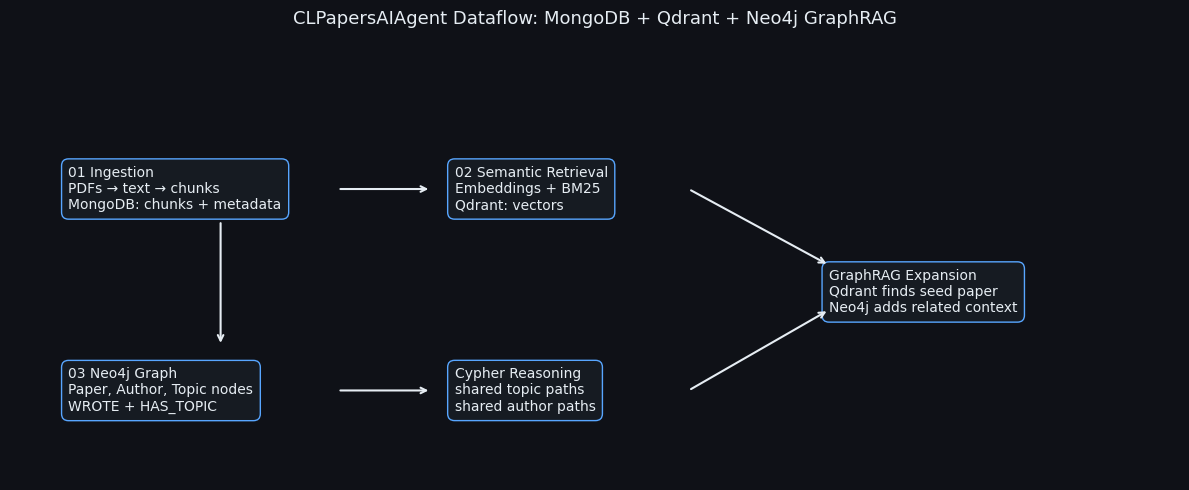

Dataflow diagram displayed and saved to: ..\notebook_cache\03_graph_build\neo4j_dataflow_diagram.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

boxes = [
    (0.05, 0.65, "01 Ingestion\nPDFs → text → chunks\nMongoDB: chunks + metadata"),
    (0.38, 0.65, "02 Semantic Retrieval\nEmbeddings + BM25\nQdrant: vectors"),
    (0.05, 0.20, "03 Neo4j Graph\nPaper, Author, Topic nodes\nWROTE + HAS_TOPIC"),
    (0.38, 0.20, "Cypher Reasoning\nshared topic paths\nshared author paths"),
    (0.70, 0.42, "GraphRAG Expansion\nQdrant finds seed paper\nNeo4j adds related context")
]

for x, y, text in boxes:
    ax.text(
        x, y, text,
        fontsize=10,
        ha="left",
        va="center",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#161b22", edgecolor="#58a6ff")
    )

arrows = [
    ((0.28, 0.65), (0.36, 0.65)),
    ((0.18, 0.58), (0.18, 0.30)),
    ((0.28, 0.20), (0.36, 0.20)),
    ((0.58, 0.20), (0.70, 0.38)),
    ((0.58, 0.65), (0.70, 0.48))
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", color="#e6edf3", lw=1.5)
    )

ax.set_title("CLPapersAIAgent Dataflow: MongoDB + Qdrant + Neo4j GraphRAG", fontsize=13)
plt.tight_layout()
plt.savefig(NOTEBOOK_CACHE / "neo4j_dataflow_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

print("Dataflow diagram displayed and saved to:", NOTEBOOK_CACHE / "neo4j_dataflow_diagram.png")

In [22]:
topic_assignment_path = NOTEBOOK_CACHE / "neo4j_topic_assignments.csv"
graph_summary_path = NOTEBOOK_CACHE / "neo4j_graph_summary.csv"

topic_assignment_df.to_csv(topic_assignment_path, index=False)
graph_summary_df.to_csv(graph_summary_path, index=False)

print("Saved topic assignments:", topic_assignment_path)
print("Saved graph summary:", graph_summary_path)

display(topic_assignment_df.head(20))
display(graph_summary_df)

Saved topic assignments: ..\notebook_cache\03_graph_build\neo4j_topic_assignments.csv
Saved graph summary: ..\notebook_cache\03_graph_build\neo4j_graph_summary.csv


,paper_id,title,topic,topic_type,source,evidence,confidence,tfidf_score,doc_frequency
0,paper1,FlexSQL: Flexible Exploration and Execution Ma...,Text-to-SQL,controlled,controlled_title,text-to-sql,0.95,NaN,NaN
1,paper1,FlexSQL: Flexible Exploration and Execution Ma...,Code Generation,controlled,controlled_abstract,coding agent,0.82,NaN,NaN
2,paper1,FlexSQL: Flexible Exploration and Execution Ma...,Reasoning,controlled,controlled_abstract,reasoning,0.82,NaN,NaN
3,paper2,Reinforcement Learning for LLM-based Multi-Age...,Large Language Models,controlled,controlled_title,llm,0.95,NaN,NaN
4,paper2,Reinforcement Learning for LLM-based Multi-Age...,LLM Agents,controlled,controlled_abstract,llm agents,0.82,NaN,NaN
5,paper2,Reinforcement Learning for LLM-based Multi-Age...,Safety and Bias,controlled,controlled_abstract,safety,0.82,NaN,NaN
6,paper3,mdok-style at SemEval-2026 Task 10: Finetuning...,Large Language Models,controlled,controlled_title,llms,0.95,NaN,NaN
7,paper3,mdok-style at SemEval-2026 Task 10: Finetuning...,Text Classification,controlled,controlled_abstract,text classification,0.82,NaN,NaN
8,paper4,mdok-style at SemEval-2026 Task 9: Finetuning ...,Large Language Models,controlled,controlled_title,llms,0.95,NaN,NaN
9,paper4,mdok-style at SemEval-2026 Task 9: Finetuning ...,Multilingual NLP,controlled,controlled_title,multilingual,0.95,NaN,NaN


,graph_item,count
0,papers,208
1,authors,951
2,topics,286
3,WROTE relationships,981
4,HAS_TOPIC relationships,776
5,SUBTOPIC_OF relationships,23
